In [123]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

In [124]:
df = pd.read_csv("/Users/juberry/Documents/Code/Machine-Learning/Data/Logistic Regression/train.csv")
df = df.drop_duplicates()
print(df.shape)

df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [125]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [126]:
df = df.dropna(subset=["Age"])
df = df.dropna(subset=["Embarked"])

In [127]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         0
dtype: int64

In [128]:
df.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    str    
 4   Sex          712 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    str    
 9   Fare         712 non-null    float64
 10  Cabin        183 non-null    str    
 11  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 101.4 KB


In [129]:
label = LabelEncoder()
df["Sex"] = label.fit_transform(df["Sex"])
df["Embarked"] = label.fit_transform(df["Embarked"])
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Embarked"]].values
y = df["Survived"].values
print(X[:5])
print(y[:5])

[[ 3.  1. 22.  1.  0.  2.]
 [ 1.  0. 38.  1.  0.  0.]
 [ 3.  0. 26.  0.  0.  2.]
 [ 1.  0. 35.  1.  0.  2.]
 [ 3.  1. 35.  0.  0.  2.]]
[0 1 1 1 0]


In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(569, 6) (143, 6)
(569,) (143,)


In [131]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])


[[-0.28934006 -1.31741297  0.24100362  0.52133471  1.89356532  0.49421974]
 [-0.28934006 -1.31741297  0.87559868  0.52133471 -0.48226416  0.49421974]
 [-0.28934006  0.75906343 -0.32308088 -0.54956583 -0.48226416  0.49421974]
 [-1.49105172  0.75906343  0.73457755 -0.54956583 -0.48226416 -2.13392074]
 [-1.49105172 -1.31741297 -0.74614426  0.52133471 -0.48226416 -2.13392074]]


In [132]:
logistic = LogisticRegression()

logistic.fit(X_train, y_train)

y_pred = logistic.predict(X_test)

accuracy = accuracy_score(y_pred, y_test)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 81.12%


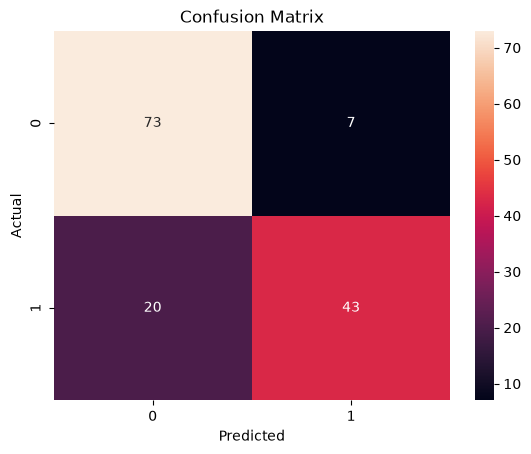

In [133]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [134]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84        80
           1       0.86      0.68      0.76        63

    accuracy                           0.81       143
   macro avg       0.82      0.80      0.80       143
weighted avg       0.82      0.81      0.81       143



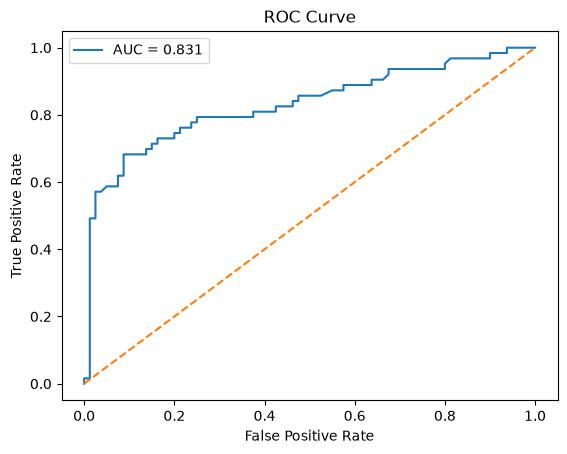

In [137]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = logistic.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

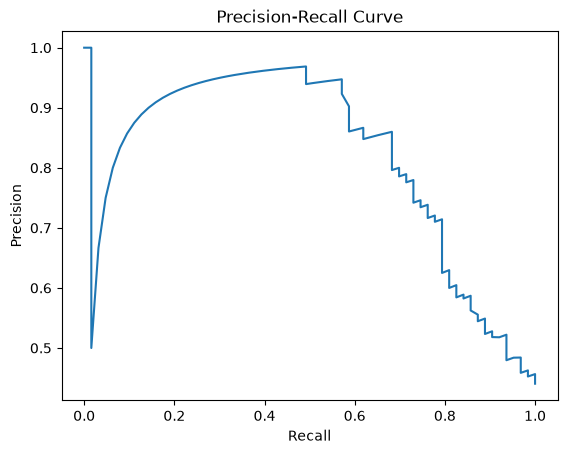

In [138]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test, y_proba
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()